In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

In [6]:
df = pd.read_csv("resume_data.csv")

print(df.shape)

df.head()

(9544, 35)


,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [7]:
df = df.drop_duplicates()

df = df.fillna("")

print(df.isnull().sum())

address                                0
career_objective                       0
skills                                 0
educational_institution_name           0
degree_names                           0
passing_years                          0
educational_results                    0
result_types                           0
major_field_of_studies                 0
professional_company_names             0
company_urls                           0
start_dates                            0
end_dates                              0
related_skils_in_job                   0
positions                              0
locations                              0
responsibilities                       0
extra_curricular_activity_types        0
extra_curricular_organization_names    0
extra_curricular_organization_links    0
role_positions                         0
languages                              0
proficiency_levels                     0
certification_providers                0
certification_sk

In [8]:
nltk.download('stopwords', quiet=True)

True

In [9]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

In [10]:
df['clean_resume'] = (
    df['skills'].astype(str)
    + " " +
    df['career_objective'].astype(str)
)

df['clean_resume'] = df['clean_resume'].apply(clean_text)

df[['clean_resume']].head()

,clean_resume
0,big data hadoop hive python mapreduce spark ja...
1,data analysis data analytics business analysis...
2,software development machine learning deep lea...
3,accounts payables accounts receivables account...
4,analytical reasoning compliance testing knowle...


In [11]:
def extract_skills(text):

    skills = str(text).lower().split(',')

    skills = [s.strip() for s in skills if s.strip()]

    return set(skills)

In [12]:
df['resume_skill_set'] = df['skills'].apply(extract_skills)

df['required_skill_set'] = df['skills_required'].apply(extract_skills)

df[['resume_skill_set','required_skill_set']].head()

,resume_skill_set,required_skill_set
0,"{'dbms', 'data structures', 'hadoop', 'yarn', ...",{}
1,"{'r', 'tableau', 'business analysis', 'powerbi...",{}
2,"{'application support', 'machine learning', 'd...",{brand promotion\ncampaign management\nfield s...
3,"{'customer service', 'email', 'bi', 'enterpris...",{fast typing skill\nieltsinternet browsing & o...
4,"{'compliance testing knowledge', 'tax returns'...",{ios\nios app developer\nios application devel...


In [13]:
df['matched_skills'] = df.apply(
    lambda row:
    list(
        row['resume_skill_set'].intersection(
            row['required_skill_set']
        )
    ),
    axis=1
)

df[['matched_skills']].head()

,matched_skills
0,[]
1,[]
2,[]
3,[]
4,[]


In [14]:
df['missing_skills'] = df.apply(
    lambda row:
    list(
        row['required_skill_set']
        -
        row['resume_skill_set']
    ),
    axis=1
)

df[['missing_skills']].head()

,missing_skills
0,[]
1,[]
2,[brand promotion\ncampaign management\nfield s...
3,[fast typing skill\nieltsinternet browsing & o...
4,[ios\nios app developer\nios application devel...


In [15]:
df['skill_match_score'] = df.apply(
    lambda row:
    (
        len(row['matched_skills'])
        /
        len(row['required_skill_set'])
        * 100
    )
    if len(row['required_skill_set']) > 0
    else 0,
    axis=1
)

df[['skill_match_score']].head()

,skill_match_score
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [16]:
ranking = df.sort_values(
    by='skill_match_score',
    ascending=False
)

ranking[
[
'skill_match_score',
'matched_skills',
'missing_skills'
]
].head(10)

,skill_match_score,matched_skills,missing_skills
9543,0.0,[],[autocad\netabs\nmicrosoft office suite\nms pr...
0,0.0,[],[]
1,0.0,[],[]
2,0.0,[],[brand promotion\ncampaign management\nfield s...
3,0.0,[],[fast typing skill\nieltsinternet browsing & o...
4,0.0,[],[ios\nios app developer\nios application devel...
5,0.0,[],[python\nr or java\ntensorflow\npytorch\nsciki...
6,0.0,[],[ios\nios app developer\nios application devel...
9527,0.0,[],[azure\nbig data\ndata analytics\netl tools\np...
9526,0.0,[],[autocad\netabs\nmicrosoft office suite\nms pr...


In [17]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(
    df['clean_resume']
)

print(X.shape)

(9544, 2955)


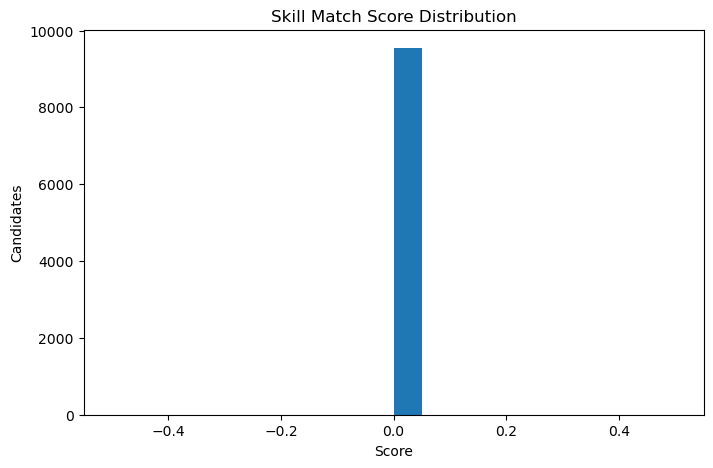

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    df['skill_match_score'],
    
    bins=20
)

plt.title("Skill Match Score Distribution")

plt.xlabel("Score")

plt.ylabel("Candidates")

plt.show()

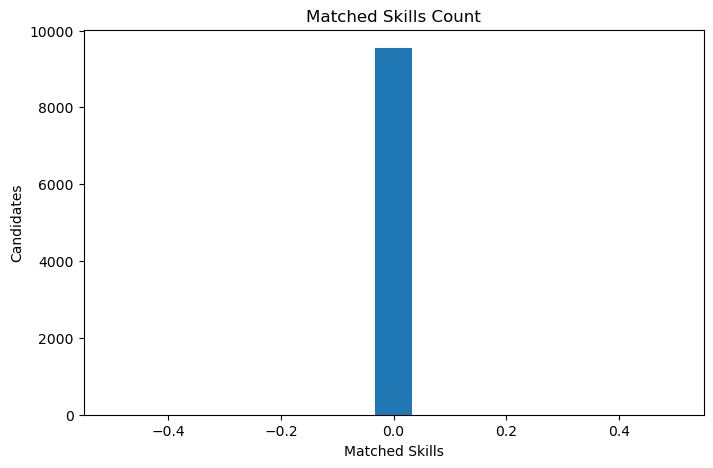

In [19]:
df['matched_count'] = df['matched_skills'].apply(len)

plt.figure(figsize=(8,5))

plt.hist(
    df['matched_count'],
    bins=15
)

plt.title("Matched Skills Count")

plt.xlabel("Matched Skills")

plt.ylabel("Candidates")

plt.show()

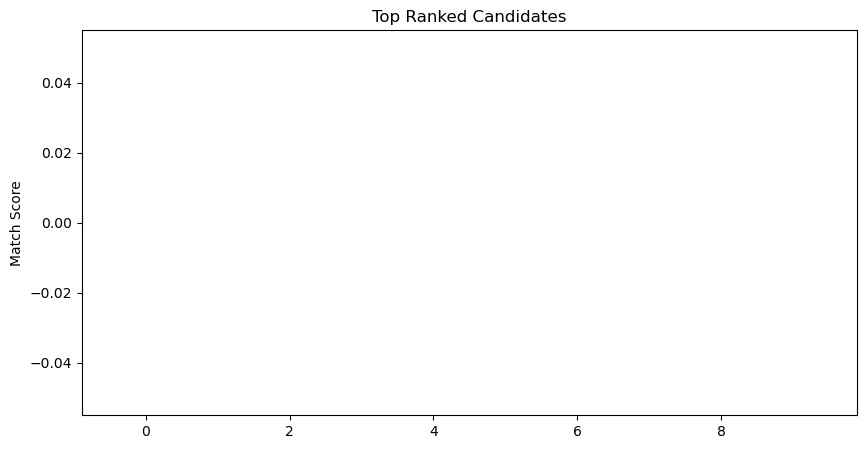

In [20]:
top10 = ranking.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top10)),
    top10['skill_match_score']
)

plt.title("Top Ranked Candidates")

plt.ylabel("Match Score")

plt.show()

In [21]:
final_output = ranking[
[
'skill_match_score',
'matched_skills',
'missing_skills'
]
]

final_output.head(20)

,skill_match_score,matched_skills,missing_skills
9543,0.0,[],[autocad\netabs\nmicrosoft office suite\nms pr...
0,0.0,[],[]
1,0.0,[],[]
2,0.0,[],[brand promotion\ncampaign management\nfield s...
3,0.0,[],[fast typing skill\nieltsinternet browsing & o...
4,0.0,[],[ios\nios app developer\nios application devel...
5,0.0,[],[python\nr or java\ntensorflow\npytorch\nsciki...
6,0.0,[],[ios\nios app developer\nios application devel...
9527,0.0,[],[azure\nbig data\ndata analytics\netl tools\np...
9526,0.0,[],[autocad\netabs\nmicrosoft office suite\nms pr...
